# Limit cycle and performance of Braitenberg strategy in the limit of zero twist

## imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pyquaternion import Quaternion
from scipy.interpolate import RBFInterpolator

## Useful functions

In [3]:
# Flows
def flow_stokeslet(e, x):
    x = np.array(x)
    r = np.linalg.norm(x)
    return (1 / r) * (e + np.tensordot(e, x, axes=[-1, -1]) * x / r**2)


def flow_stresslet(e, x):
    x = np.array(x)
    r = np.linalg.norm(x)
    return (1 / r**2) * (
        -x / r
        + 3 * np.tensordot(e, x, axes=[-1, -1])[..., np.newaxis] ** 2 * x / r**3
    )

# This is wrong
# Gradients
def gradient_stresslet(e, x):
    x = np.array(x)
    r = np.linalg.norm(x, axis=-1)
    gradflow = (
        -np.eye(3) / r**3
        + 3 * np.outer(x, x) / r**5
        + 6 * np.dot(x, e) * np.outer(e, x) / r**5
        + 3 * np.dot(x, e) ** 2 * np.eye(3) / r**5
        - 15 * np.dot(x, e) ** 2 * np.outer(x, x) / r**7
    )
    return gradflow


# Strains (symmetric part of gradient)
def strain_stokeslet(e, x):
    x = np.array(x)
    r = np.linalg.norm(x, axis=-1)
    return -(1 / r**2) * (
        -np.dot(x, e) * np.eye(3) / r + 3 * np.dot(x, e) * np.outer(x, x) / r**3
    )


def strain_stresslet(e, x):
    r = np.linalg.norm(x, axis=-1)
    g1 = (
        np.outer(x, x)
        + np.dot(e, x) ** 2 * np.eye(3)
        + np.dot(e, x) * (np.outer(x, e) + np.outer(e, x))
    )
    return -(1 / r**3) * (
        np.eye(3) + 15 * np.dot(e, x) ** 2 * np.outer(x, x) / r**4 - 3 * g1 / r**2
    )

In [7]:
e = np.array([0,0,1])
x = np.array([3,1,1])
gradient_stresslet(e,x)

array([[ 0.01676322,  0.01223262,  0.01223262],
       [ 0.01223262, -0.0158571 ,  0.00407754],
       [ 0.05708554,  0.01902851, -0.00090612]])

In [8]:
def Braitenberg_angular_speed(n, x, e, gradient):
    """Finite difference implementation of Braitenberg angularspeed"""
    eps = 1e-6
    x1 = x + eps * n
    x2 = x - eps * n

    # Flow measured in the cope reference system
    gradient1 = np.dot(n, gradient(e, x1))
    gradient2 = np.dot(n, gradient(e, x2))
    S1 = np.linalg.norm(gradient1)
    S2 = np.linalg.norm(gradient2)
    return (S1 - S2) / (2 * eps)

In [9]:
def position_from_spherical_coordinates(r, theta, phi):
    x = np.array(
        [
            r * np.cos(phi) * np.sin(theta),
            r * np.sin(phi) * np.sin(theta),
            r * np.cos(theta),
        ]
    )
    return x.T

In [10]:
# function used to compute the dynamics in the limit of zero twist
def find_stable_angles(b, Nn, interpolator):
    A = interpolator(b[np.newaxis, :]).reshape(-1)
    rot_angle2 = np.linspace(0, 2 * np.pi, num=128, endpoint=False)
    kn = np.fft.fftfreq(Nn, d=2 * np.pi / Nn)
    omega = np.sum(
        A[:, np.newaxis].real
        / Nn
        * np.cos(2 * np.pi * rot_angle2[np.newaxis, :] * kn[:, np.newaxis])
        - A[:, np.newaxis].imag
        / Nn
        * np.sin(2 * np.pi * rot_angle2[np.newaxis, :] * kn[:, np.newaxis]),
        axis=0,
    )

    Pomega = omega[1:] * omega[:-1] < 0
    Domega = omega[1:] - omega[:-1] < 0
    r1 = rot_angle2[1:]
    r2 = rot_angle2[:-1]
    o1 = omega[1:]
    o2 = omega[:-1]
    r = (o1 * r2 - o2 * r1) / (o1 - o2)
    return r[Pomega * Domega]


def find_angle(b, t):
    t0 = [1, 2, 7]
    n0 = np.cross(b, t0)
    n0 /= np.linalg.norm(n0)
    return np.mod(np.arctan2(np.dot(t, n0), np.dot(t, t0)), 2 * np.pi)

## Tests

In [11]:
flow = flow_stresslet  # flow_stokeslet, flow_stresslet
grad = gradient_stresslet
strain = strain_stresslet
e = np.array([0, 0, 1])
eps = 1e-8

pos = np.random.rand(3)
dir1 = np.random.rand(3)
dir2 = np.random.rand(3)
dir1 /= np.linalg.norm(dir1)
dir2 /= np.linalg.norm(dir2)

gradapprox1 = np.dot((flow(e, pos + eps * dir1) - flow(e, pos)) / eps, dir2)
gradapprox2 = np.dot((flow(e, pos + eps * dir2) - flow(e, pos)) / eps, dir1)

approx_gradient = gradapprox1
approx_strain = (gradapprox1 + gradapprox2) / 2
exact_gradient = np.dot(np.dot(dir1, grad(e, pos)), dir2)
exact_strain = np.dot(np.dot(dir1, strain(e, pos)), dir2)

assert np.isclose(approx_gradient, exact_gradient), "problem with gradient"
assert np.isclose(approx_strain, exact_strain), "problem with strain"

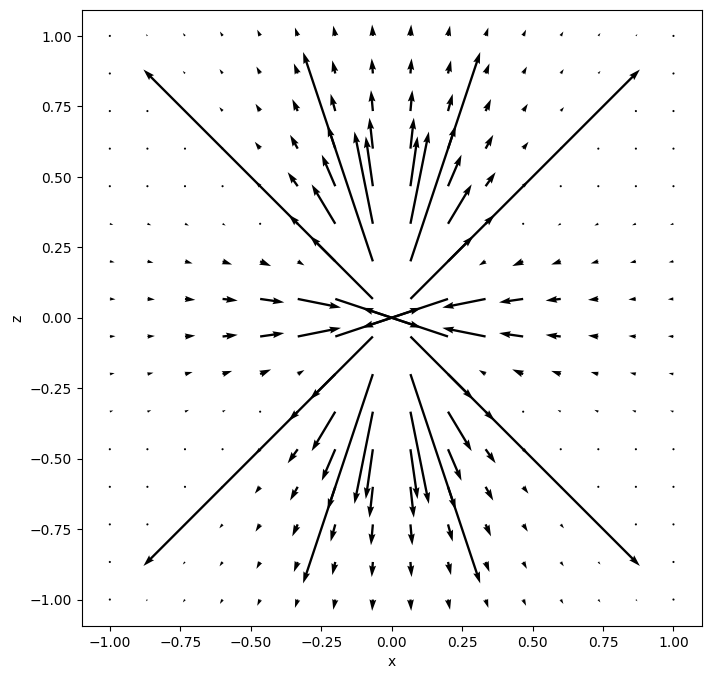

In [12]:
x = np.linspace(-1, 1, num=16)
X, Z = np.meshgrid(x, x)
x = X.reshape(-1)
z = Z.reshape(-1)
N = len(x)
u, v, w = 0 * x, 0 * x, 0 * x

for i in range(N):
    u[i], v[i], w[i] = flow(e, [x[i], 0, z[i]])

assert np.allclose(v, 0)

plt.figure(figsize=(8, 8))
plt.quiver(x, z, u, w)
plt.xlabel("x")
plt.ylabel("z")
plt.axis("equal")

plt.show()

## Parameters and initializations

In [34]:
grad = strain_stresslet # Note: it should work with a strain or another flow
grad_name = "StrainStresslet"
Nagent = 17  # number of agent positions (in the quarter circle of radius 1)
Nmean = 128  # points on the sphere (starting point of b to do the averages)
Nsphere = 128  # points on the sphere (to interpolate b)
Nfourier = 32  # number of Fourier coefficients to evaluation omega_Braitenberg(alpha)
Nsteps = 128  # number of timesteps per twist, when computing the dynamics of (t,n,b)
Nperiods = 4  # number of twist periods (only the last one is used for averages)
e = np.array([0, 0, 1])  # orientation of the flow

## Initializations

In [23]:
# initialisation of arrays
agent_thetas = np.linspace(0, np.pi / 2, num=Nagent, endpoint=True)
agent_positions = np.array(
    [np.sin(agent_thetas), 0 * agent_thetas, np.cos(agent_thetas)]
).T

alphas = np.linspace(0, 2 * np.pi, num=Nfourier, endpoint=False)
times = np.linspace(0, Nperiods * 2 * np.pi, num=Nperiods * Nsteps, endpoint=False)
dt = times[1]
omega = np.zeros((Nfourier))
fourier_coeffs = np.zeros((Nagent, Nsphere, Nfourier), dtype=np.cdouble)

t0 = np.zeros((Nsphere, 3))
n0 = np.zeros((Nsphere, 3))
b0 = np.zeros((Nsphere, 3))

tinit = np.zeros((Nmean, 3))
ninit = np.zeros((Nmean, 3))
binit = np.zeros((Nmean, 3))

tstep = np.zeros((Nagent, Nmean, Nperiods * Nsteps, 3))
nstep = np.zeros((Nagent, Nmean, Nperiods * Nsteps, 3))
bstep = np.zeros((Nagent, Nmean, Nperiods * Nsteps, 3))

In [24]:
# Positions used for interpolation (Fibonnaci spiral)
# http://extremelearning.com.au/how-to-evenly-distribute-points-on-a-sphere-more-effectively-than-the-canonical-fibonacci-lattice
goldenRatio = (1 + 5**0.5) / 2

i = np.arange(0, Nsphere)
phi0 = np.mod(2 * np.pi * i / goldenRatio, 2 * np.pi)
theta0 = np.arccos(1 - 2 * (i + 0.5) / Nsphere)

b0[:, 0] = np.cos(phi0) * np.sin(theta0)
b0[:, 1] = np.sin(phi0) * np.sin(theta0)
b0[:, 2] = np.cos(theta0)

for i in range(Nsphere):
    b = b0[i]
    t = [1, 2, 7]
    n0[i] = np.cross(b0[i], t)
    n0[i] /= np.linalg.norm(n0[i])
    t0[i] = np.cross(n0[i], b0[i])

# Initial positions
i = np.arange(0, Nmean)
phi_init = np.mod(2 * np.pi * i / goldenRatio, 2 * np.pi)
theta_init = np.arccos(1 - 2 * (i + 0.5) / Nmean)
tinit = np.zeros((Nmean, 3))
ninit = np.zeros((Nmean, 3))
binit = np.zeros((Nmean, 3))

binit[:, 0] = np.cos(phi_init) * np.sin(theta_init)
binit[:, 1] = np.sin(phi_init) * np.sin(theta_init)
binit[:, 2] = np.cos(theta_init)

for i in range(Nmean):
    b = binit[i]
    t = np.random.rand(3)
    ninit[i] = np.cross(binit[i], t)
    ninit[i] /= np.linalg.norm(ninit[i])
    tinit[i] = np.cross(ninit[i], binit[i])

## Interpolation from a discrete set of directions b

In [25]:
# Calculation of omega(alpha) and their Fourier coefficients
for a in range(Nagent):
    agent_position = agent_positions[a]
    for i in range(Nsphere):
        for j, alpha in enumerate(alphas):
            n = np.cos(alpha) * n0[i] - np.sin(alpha) * t0[i]
            omega[j] = Braitenberg_angular_speed(n, agent_position, e, grad)
        fourier_coeffs[a, i] = np.fft.fft(omega)

In [26]:
# Create the interpolators
interpolators = []  # one per agent's position
for a in range(Nagent):
    interpolators.append(
        RBFInterpolator(
            position_from_spherical_coordinates(1, theta0, phi0),
            fourier_coeffs[a],
        )
    )

## Dynamics of (t,n,b) and limit cycles

In [27]:
for a in range(Nagent):
    for init in range(Nmean):
        print(
            "agent position %d / %d | initial orientation %d / %d    "
            % (a + 1, Nagent, init + 1, Nmean),
            end="\r",
        )
        t = tinit[init]
        n = ninit[init]
        b = binit[init]

        for i, time in enumerate(times):
            # record angles
            tstep[a, init, i] = t
            nstep[a, init, i] = n
            bstep[a, init, i] = b

            # Calculating ref directions nref, tref
            tref = [1, 2, 7]
            nref = np.cross(b, tref)
            nref /= np.linalg.norm(nref)
            tref = np.cross(nref, b)

            # find stable angles and current angle for b, t
            stable_angles = find_stable_angles(b, Nfourier, interpolators[a])
            angle = find_angle(b, t)

            # find new stable angle for t
            A = interpolators[a](b[np.newaxis, :]).reshape(-1)
            kn = np.fft.fftfreq(Nfourier, d=2 * np.pi / Nfourier)
            omega_angle = np.sum(
                A.real / Nfourier * np.cos(2 * np.pi * angle * kn)
                - A.imag / Nfourier * np.sin(2 * np.pi * angle * kn),
            )

            if len(stable_angles) > 0:
                if omega_angle > 0:
                    dist = np.mod(stable_angles - angle, 2 * np.pi)
                    new_angle = stable_angles[np.argmin(dist[dist > 0])]
                else:
                    dist = np.mod(angle - stable_angles, 2 * np.pi)
                    new_angle = stable_angles[np.argmin(dist[dist > 0])]

                t = np.cos(new_angle) * tref + np.sin(new_angle) * nref
                n = np.cos(new_angle) * nref - np.sin(new_angle) * tref

            # rotation around t
            Rotation_t = Quaternion(axis=t, angle=dt)
            n = Rotation_t.rotate(n)
            b = Rotation_t.rotate(b)

## Averages and plots

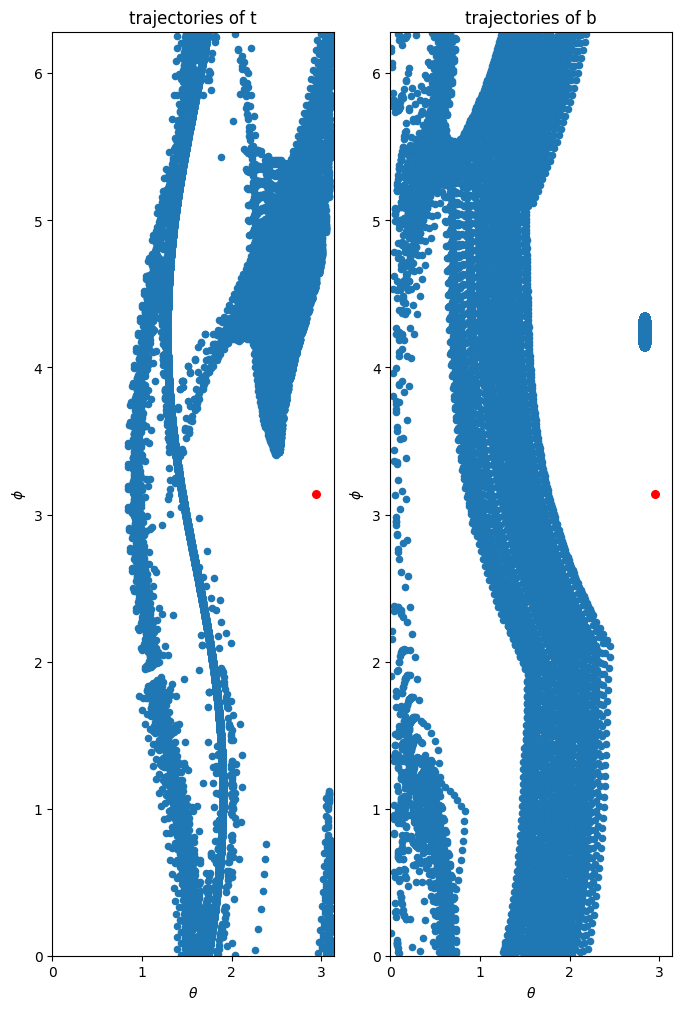

In [28]:
n_agent_position = 2

x = -agent_positions[n_agent_position]
x /= np.linalg.norm(x)
theta_target = np.arccos(x[2])
phi_target = np.arctan2(x[1], x[0])
phi_target = np.mod(phi_target, 2 * np.pi)

fig = plt.figure(figsize=(8, 12))

#
ax = fig.add_subplot(121)

theta_ = np.arccos(tstep[n_agent_position, ..., 2])
phi_ = np.mod(
    np.arctan2(tstep[n_agent_position, ..., 1], tstep[n_agent_position, ..., 0]),
    2 * np.pi,
)

ax.scatter(
    theta_[:, (Nperiods - 1) * Nsteps :],
    phi_[:, (Nperiods - 1) * Nsteps :],
    marker="o",
    s=20,
)

ax.scatter(theta_target, phi_target, marker="o", s=30, color="r")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
ax.set_title("trajectories of t")
ax.set_xlim([-0 * np.pi / 2, 2 * np.pi / 2])
ax.set_ylim([-0 * np.pi, 2 * np.pi])

#
ax = fig.add_subplot(122)

theta_ = np.arccos(bstep[n_agent_position, ..., 2])
phi_ = np.mod(
    np.arctan2(bstep[n_agent_position, ..., 1], bstep[n_agent_position, ..., 0]),
    2 * np.pi,
)

ax.scatter(
    theta_[:, (Nperiods - 1) * Nsteps :],
    phi_[:, (Nperiods - 1) * Nsteps :],
    marker="o",
    s=20,
)

ax.scatter(theta_target, phi_target, marker="o", s=30, color="r")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
ax.set_title("trajectories of b")
ax.set_xlim([-0 * np.pi / 2, 2 * np.pi / 2])
ax.set_ylim([-0 * np.pi, 2 * np.pi])

plt.show()

In [29]:
# Calculation of performance
gamma_perf = np.zeros(Nagent)
tmean = np.zeros((Nagent, 3))

for a in range(Nagent):
    agent_position = agent_positions[a]
    t = tstep[a, :, (Nperiods - 1) * Nsteps:, :]
    t_mean = np.mean(t, axis=(0, 1))
    tmean[a] = t_mean
    gamma_perf[a] = np.dot(tmean[a], -agent_position)
    
print("y component of strategy", tmean[:,1])

y component of strategy [-0.07995011 -0.11557661 -0.17172241 -0.19346338 -0.17484024 -0.20480156
 -0.19027885 -0.17133559 -0.14767306 -0.10865542 -0.07131239 -0.04304761
 -0.03406126 -0.03604309 -0.02346359 -0.02512709 -0.02766855]


<function matplotlib.pyplot.show(close=None, block=None)>

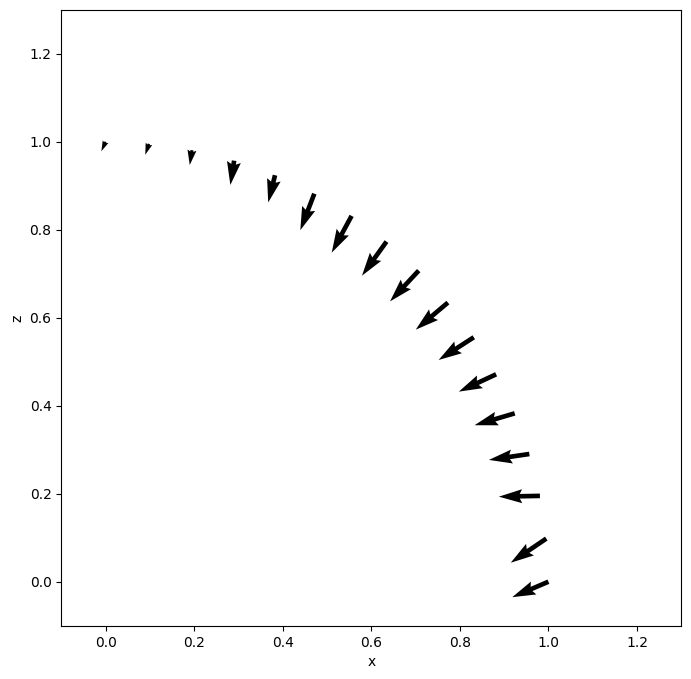

In [30]:
plt.figure(figsize=(8,8))
plt.quiver(
    agent_positions[:,0],
    agent_positions[:,2],
    tmean[:,0],
    tmean[:,2],
)

plt.xlim([-0.1, 1.3])
plt.ylim([-0.1, 1.3])
plt.xlabel('x')
plt.ylabel('z')

plt.show

# 2D plot

In [52]:
# 
#
Npoints = 128
r = np.linspace(0.1, 5, Npoints) # x axis
print(agent_positions)
X, Z = np.meshgrid(x, z)
T_mean = np.zeros((Npoints, Npoints, 3))
Perf = np.zeros((Npoints, Npoints))
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        angular_agent_position = np.arctan2(Z[i,j], X[i,j])
        agent_equivalent_position = np.array([np.sin(angular_agent_position), 0, np.cos(angular_agent_position)])
        a = (np.abs(np.linalg.norm(agent_positions - agent_equivalent_position, axis = 1))).argmin()
        agent_position = agent_positions[a]
        T_mean[i, j] = tmean[a]
        Perf[i, j] = np.dot(T_mean[i, j], -agent_positions[a])

[[0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [9.80171403e-02 0.00000000e+00 9.95184727e-01]
 [1.95090322e-01 0.00000000e+00 9.80785280e-01]
 [2.90284677e-01 0.00000000e+00 9.56940336e-01]
 [3.82683432e-01 0.00000000e+00 9.23879533e-01]
 [4.71396737e-01 0.00000000e+00 8.81921264e-01]
 [5.55570233e-01 0.00000000e+00 8.31469612e-01]
 [6.34393284e-01 0.00000000e+00 7.73010453e-01]
 [7.07106781e-01 0.00000000e+00 7.07106781e-01]
 [7.73010453e-01 0.00000000e+00 6.34393284e-01]
 [8.31469612e-01 0.00000000e+00 5.55570233e-01]
 [8.81921264e-01 0.00000000e+00 4.71396737e-01]
 [9.23879533e-01 0.00000000e+00 3.82683432e-01]
 [9.56940336e-01 0.00000000e+00 2.90284677e-01]
 [9.80785280e-01 0.00000000e+00 1.95090322e-01]
 [9.95184727e-01 0.00000000e+00 9.80171403e-02]
 [1.00000000e+00 0.00000000e+00 6.12323400e-17]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


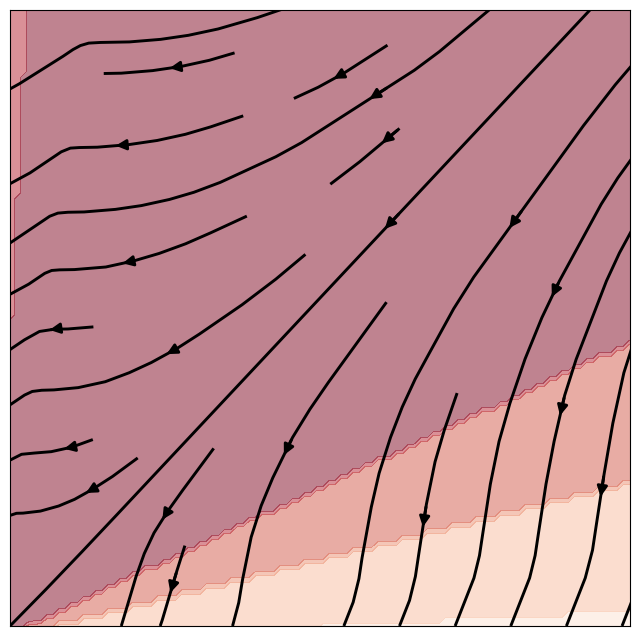

In [53]:
# Plot data from Save 

import scipy.ndimage as ndimage # import to smooth plots

# Plot parameters
CMAP = 'RdBu_r' #'spring'
STREAMCOLOR = 'black'

fig1, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,8), sharex='col', sharey='row')
ax1 = axs
X, Z = np.meshgrid(x, z, indexing='xy')

# Add data to image grid
levels = np.linspace(-1, 1.00001, 14)

im = ax1.contourf(X, Z, Perf, cmap = CMAP, levels = levels, vmin= -1, vmax = 1, alpha = 0.5)
ax1.streamplot(X, Z, T_mean[:,:,0], T_mean[:,:,2], color = STREAMCOLOR,  density = .5, linewidth = 2.1, arrowsize = 1.5, zorder = 2)
#PlotCircles(ax1, .5)
ax1.set_xlim([.1, 4])
ax1.set_ylim([.1, 4])
ax1.set_xticks([])
ax1.set_yticks([])



#plt.colorbar(im, ax = axs, ticks = np.arange(-1, 1.1, 0.5), location= 'bottom')
# Uncomment to save
plt.savefig(f"Plots/Brait_theory_{grad_name}_2.eps", format = 'eps', bbox_inches='tight')
plt.savefig(f"Plots/Brait_theory_{grad_name}_2.pdf", bbox_inches='tight')
plt.show()